In [1]:
import sys
sys.path.append('./')

sys.path.append('/Users/ASUS/Documents/GitHub/retrospective_t2e_analysis/auton-survival/')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import torch
from tqdm import tqdm 
from examples.cmhe_demo_utils import * 
from metrics import treatment_effect
from auton_survival import reporting
from matplotlib.pyplot import figure

c:\Users\ASUS\anaconda3\envs\Pandas\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load PEACE dataset
from datasets_retrospective import load_peace_dataset
outcomes, features, intervention, cat_feats, num_feats = load_peace_dataset(location='/Users/ASUS/Documents/GitHub/retrospective_t2e_analysis/auton-survival/auton_survival/datasets/', outcome='PRIMARY')

(8290, 7)
(8290, 39)
(8290, 7)
(8290, 39)


In [3]:
outcomes.time = outcomes.time / 365.25

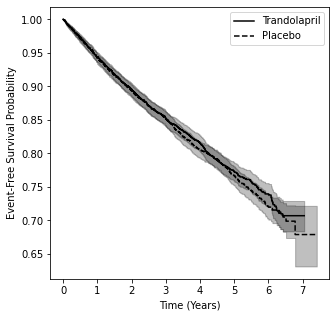

In [12]:
# Let's plot the survival curves in the original paper
figure(figsize=(5,5))
ax_0 = reporting.plot_kaplanmeier(outcomes[intervention == 'Trandolapril'], intervention[intervention == 'Trandolapril'], color = 'black', linestyle = 'solid')
ax_1 = reporting.plot_kaplanmeier(outcomes[intervention == 'Placebo'], intervention[intervention == 'Placebo'], color = 'black', linestyle = 'dashed')
plt.xlabel('Time (Years)')
plt.ylabel('Event-Free Survival Probability')
plt.savefig("PEACE paper.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [4]:
# Specify categorical and numeric features used for training the model
cat_feats_cmhe = ['Sex', 'Baseline_Smoke_status']
num_feats_cmhe = ['Baseline_Seated_Systolic_Blood_Pressure', 'Baseline_Seated_Diastolic_Blood_Pressure']

In [5]:
# Preprocess selected feature data
from preprocessing import Preprocessor
features_prep_cmhe = Preprocessor().fit_transform(data=features[cat_feats_cmhe+num_feats_cmhe], cat_feats=cat_feats_cmhe, num_feats=num_feats_cmhe)

In [6]:
# Hyper-parameters to train model
k = 1 # number of underlying base survival phenotypes
g = 2 # number of underlying treatment effect phenotypes.
layers = [] # number of neurons in each hidden layer.
random_seed = 3
iters = 100 # number of training epochs
learning_rate = 0.001
batch_size = 256 
patience = 5
optimizer = "Adam"
gate_l2_penalty = 1e-3

In [7]:
from models.cmhe import DeepCoxMixturesHeterogenousEffects

torch.manual_seed(random_seed)
np.random.seed(random_seed)

# Instantiate the CMHE model on all data
model = DeepCoxMixturesHeterogenousEffects(random_seed=10, k=k, g=g, layers=layers, gate_l2_penalty=gate_l2_penalty)

model = model.fit(features_prep_cmhe, outcomes.time, outcomes.event, intervention=='Trandolapril', val_data=None, iters=iters, 
                  learning_rate=learning_rate, batch_size=batch_size, 
                  optimizer=optimizer, patience=patience)

  0%|          | 0/100 [00:00<?, ?it/s]c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\models\cmhe\cmhe_utilities.py:121: RuntimeWarning: invalid value encountered in log
  probs.append(np.log(event_probs))
100%|██████████| 100/100 [00:34<00:00,  2.94it/s]


In [8]:
zeta_probs = model.predict_latent_phi(features_prep_cmhe)
zeta = np.argmax(zeta_probs, axis=1)

In [9]:
(zeta == 0).sum()

2640

In [10]:
sum(outcomes.event)

1838

In [11]:
outcomes[zeta == 0].event.sum() / sum(outcomes.event)

0.33133841131664854

In [12]:
outcomes[zeta == 1].event.sum() / sum(outcomes.event)

0.6686615886833515

In [13]:
(zeta == 1).sum()

5650

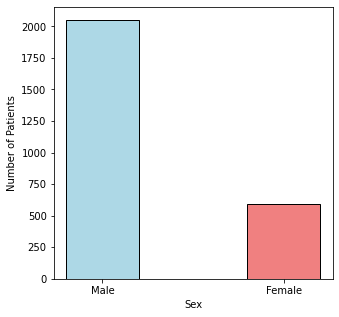

In [17]:
# Plot distribution of patients by Sex
plt.figure(figsize=(5,5))
plt.bar(['Male', 'Female'], (features.Sex)[zeta == 0].value_counts(), color = ['lightblue', 'lightcoral'],
        width = 0.4, edgecolor='black')
plt.xlabel("Sex")
plt.ylabel("Number of Patients")
# plt.title("Distribution of Patients in Zeta 0 by Sex")
plt.savefig("PEACE sex harmed.pdf", format='pdf', bbox_inches='tight')
plt.show()

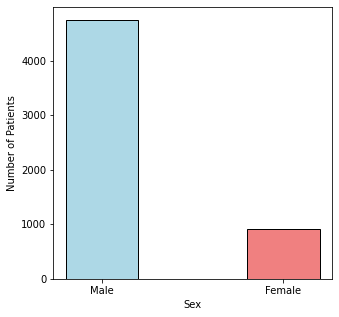

In [18]:
# Plot distribution of patients by Sex
plt.figure(figsize=(5,5))
plt.bar(['Male', 'Female'], (features.Sex)[zeta == 1].value_counts(), color = ['lightblue', 'lightcoral'],
        width = 0.4, edgecolor='black')
plt.xlabel("Sex")
plt.ylabel("Number of Patients")
# plt.title("Distribution of Patients in Zeta 1 by Sex")
plt.savefig("PEACE sex benefited.pdf", format='pdf', bbox_inches='tight')
plt.show()

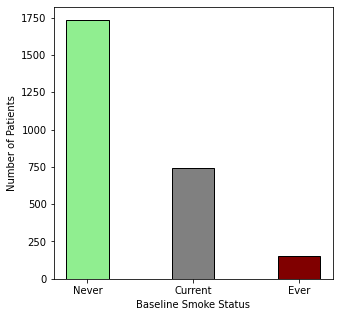

In [21]:
# Plot distribution of patients by Smoke Status
plt.figure(figsize=(5,5))
plt.bar(['Never', 'Current', 'Ever'], features[zeta == 0].Baseline_Smoke_status.value_counts(), color = ['lightgreen', 'grey', 'maroon'],
        width = 0.4, edgecolor='black')
plt.xlabel("Baseline Smoke Status")
plt.ylabel("Number of Patients")
plt.savefig("PEACE smoke harmed.pdf", format='pdf', bbox_inches='tight')
# plt.title("Distribution of Patients in Zeta 0 by Smoke Status at Baseline")
plt.show()

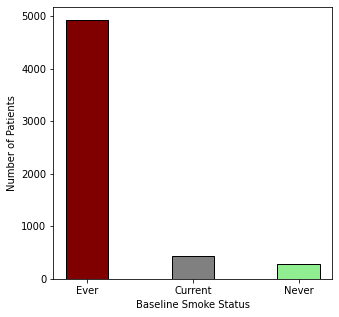

In [23]:
# Plot distribution of patients by Smoke Status
plt.figure(figsize=(5,5))
plt.bar(['Ever', 'Current', 'Never'], features[zeta == 1].Baseline_Smoke_status.value_counts(), color = ['maroon', 'grey', 'lightgreen'],
        width = 0.4, edgecolor='black')
plt.xlabel("Baseline Smoke Status")
plt.ylabel("Number of Patients")
plt.savefig("PEACE smoke benefited.pdf", format='pdf', bbox_inches='tight')
# plt.title("Distribution of Patients in Zeta 1 by Smoke Status at Baseline")
plt.show()

In [27]:
hr = treatment_effect('hazard_ratio', outcomes, intervention == 'Trandolapril', n_bootstrap=100)
CI = np.quantile(hr, [0.025, 0.975])
print(CI)
print(sum(hr)/len(hr))

c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\metrics.py:107: UserWarning: WARNING: You are computing Hazard Ratios.
 Make sure you have tested the PH Assumptions.
  warnings.warn("WARNING: You are computing Hazard Ratios.\n Make sure you have tested the PH Assumptions.")


Bootstrapping...  100  number of times. This may take a while. Please be Patient...
[0.87075059 1.05881542]
0.9585909908018152


In [24]:
hr_zeta0 = treatment_effect('hazard_ratio', outcomes[zeta == 0], intervention[zeta == 0] == 'Trandolapril', n_bootstrap=100)
CI_zeta0 = np.quantile(hr_zeta0, [0.025, 0.975])
print(CI_zeta0)
print(sum(hr_zeta0)/len(hr_zeta0))

c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\metrics.py:107: UserWarning: WARNING: You are computing Hazard Ratios.
 Make sure you have tested the PH Assumptions.
  warnings.warn("WARNING: You are computing Hazard Ratios.\n Make sure you have tested the PH Assumptions.")


Bootstrapping...  100  number of times. This may take a while. Please be Patient...
[1.03666922 1.41555366]
1.1959537487608507


In [26]:
hr_zeta1 = treatment_effect('hazard_ratio', outcomes[zeta == 1], intervention[zeta == 1] == 'Trandolapril', n_bootstrap=100)
CI_zeta1 = np.quantile(hr_zeta1, [0.025, 0.975])
print(CI_zeta1)
print(sum(hr_zeta1)/len(hr_zeta1))

c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\metrics.py:107: UserWarning: WARNING: You are computing Hazard Ratios.
 Make sure you have tested the PH Assumptions.
  warnings.warn("WARNING: You are computing Hazard Ratios.\n Make sure you have tested the PH Assumptions.")


Bootstrapping...  100  number of times. This may take a while. Please be Patient...
[0.77591736 0.98733914]
0.8625888283002855


C:\Users\ASUS\AppData\Local\Temp\ipykernel_10932\2695299689.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ax_2 = reporting.plot_kaplanmeier(outcomes[zeta==0][intervention == 'Trandolapril'], intervention[zeta==0][intervention == 'Trandolapril'], color = 'black', linestyle = 'solid')
C:\Users\ASUS\AppData\Local\Temp\ipykernel_10932\2695299689.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ax_3 = reporting.plot_kaplanmeier(outcomes[zeta==0][intervention == 'Placebo'], intervention[zeta==0][intervention == 'Placebo'], color = 'black', linestyle = 'dashed')


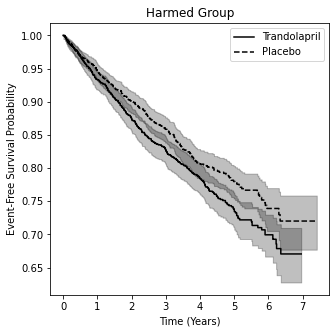

In [13]:
# Let's plot the survival curves in the original paper
figure(figsize=(5,5))
ax_2 = reporting.plot_kaplanmeier(outcomes[zeta==0][intervention == 'Trandolapril'], intervention[zeta==0][intervention == 'Trandolapril'], color = 'black', linestyle = 'solid')
ax_3 = reporting.plot_kaplanmeier(outcomes[zeta==0][intervention == 'Placebo'], intervention[zeta==0][intervention == 'Placebo'], color = 'black', linestyle = 'dashed')
plt.title('Harmed Group')
plt.xlabel('Time (Years)')
plt.ylabel('Event-Free Survival Probability')
plt.savefig("PEACE harmed.pdf", format='pdf', bbox_inches='tight')
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_10932\2649356017.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ax_4 = reporting.plot_kaplanmeier(outcomes[zeta==1][intervention == 'Trandolapril'], intervention[zeta==1][intervention == 'Trandolapril'], color = 'black', linestyle = 'solid')
C:\Users\ASUS\AppData\Local\Temp\ipykernel_10932\2649356017.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ax_5 = reporting.plot_kaplanmeier(outcomes[zeta==1][intervention == 'Placebo'], intervention[zeta==1][intervention == 'Placebo'], color = 'black', linestyle = 'dashed')


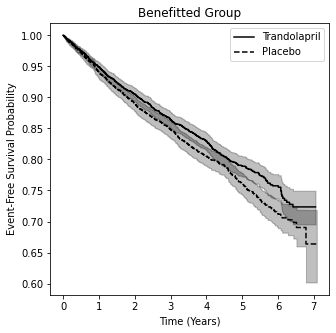

In [14]:
# Let's plot the survival curves in the original paper
figure(figsize=(5,5))
ax_4 = reporting.plot_kaplanmeier(outcomes[zeta==1][intervention == 'Trandolapril'], intervention[zeta==1][intervention == 'Trandolapril'], color = 'black', linestyle = 'solid')
ax_5 = reporting.plot_kaplanmeier(outcomes[zeta==1][intervention == 'Placebo'], intervention[zeta==1][intervention == 'Placebo'], color = 'black', linestyle = 'dashed')
plt.title('Benefitted Group')
plt.xlabel('Time (Years)')
plt.ylabel('Event-Free Survival Probability')
plt.savefig("PEACE benefitted.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [8]:
from sklearn import tree # Import the decision tree namespace
from sklearn.metrics import plot_confusion_matrix # Generate a confusion matrix

In [9]:
# Get the features to train Decision Tree Classifier
features_dt = pd.merge(features[num_feats_cmhe], features_prep_cmhe.drop(num_feats_cmhe, axis=1), left_index=True, right_index=True, how='inner')
features_dt

,Baseline_Seated_Systolic_Blood_Pressure,Baseline_Seated_Diastolic_Blood_Pressure,Sex_Male,Baseline_Smoke_status_Ever,Baseline_Smoke_status_Never
NEW_ID,,,,,
10007.0,150.0,80.0,1,0,1
10026.0,142.0,91.0,1,1,0
10027.0,115.0,70.0,1,1,0
10040.0,140.0,82.0,1,0,1
10042.0,126.0,78.0,1,0,1
...,...,...,...,...,...
99957.0,177.0,99.0,1,1,0
99959.0,130.0,64.0,1,1,0
99968.0,135.0,80.0,1,1,0


In [10]:
from sklearn.model_selection import train_test_split

# Split the PEACE data into training and test data
x_train, x_test, y_train, y_test = train_test_split(features_dt, outcomes, test_size=0.3, random_state=1, 
                                          stratify = outcomes.event + 2*(intervention=='Trandolapril'))

print(f'Number of training data points: {len(x_train)}')
print(f'Number of test data points: {len(x_test)}')

Number of training data points: 5803
Number of test data points: 2487


In [11]:
# Get the Zeta for Train data
idxs = x_train.dropna(axis=0).index.values.astype(int)
f_idxs = features_prep_cmhe.index.values.astype(int)
mask = np.in1d(f_idxs, idxs)

# Get the Zeta for Test data
idxs2 = x_test.dropna(axis=0).index.values.astype(int)
f_idxs2 = features_prep_cmhe.index.values.astype(int)
mask2 = np.in1d(f_idxs2, idxs2)

In [12]:
# Create and fit the model using entropy separation and a maximum depth
# Drop NaNs because the feature columns not preprocessed i.e. 
# Numerical features have NaNs 
dt_model = tree.DecisionTreeClassifier(criterion='entropy', max_depth=3)
dt_model.fit(x_train.dropna(axis=0), zeta[mask])

DecisionTreeClassifier(criterion='entropy', max_depth=3)

c:\Users\ASUS\anaconda3\envs\Pandas\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


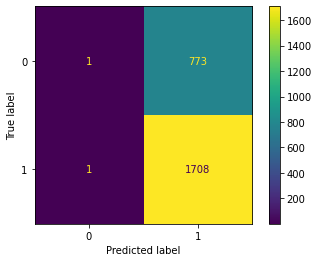

In [13]:
# Plot the confusion matrix
plot_confusion_matrix(dt_model, x_test.dropna(axis = 0), zeta[mask2], values_format='d', labels=[0, 1])

In [14]:
# Get the accuracy of test and train data
from sklearn.model_selection import cross_validate
scoring = ['accuracy','precision', 'recall', 'f1']
scores = cross_validate(dt_model, x_train.dropna(axis = 0), zeta[mask], scoring=scoring, return_train_score=True, cv=5)
results = pd.DataFrame(scores)
results.mean()

fit_time           0.004178
score_time         0.005199
test_accuracy      0.678159
train_accuracy     0.679883
test_precision     0.679294
train_precision    0.680005
test_recall        0.996701
train_recall       0.998604
test_f1            0.807940
train_f1           0.809069
dtype: float64

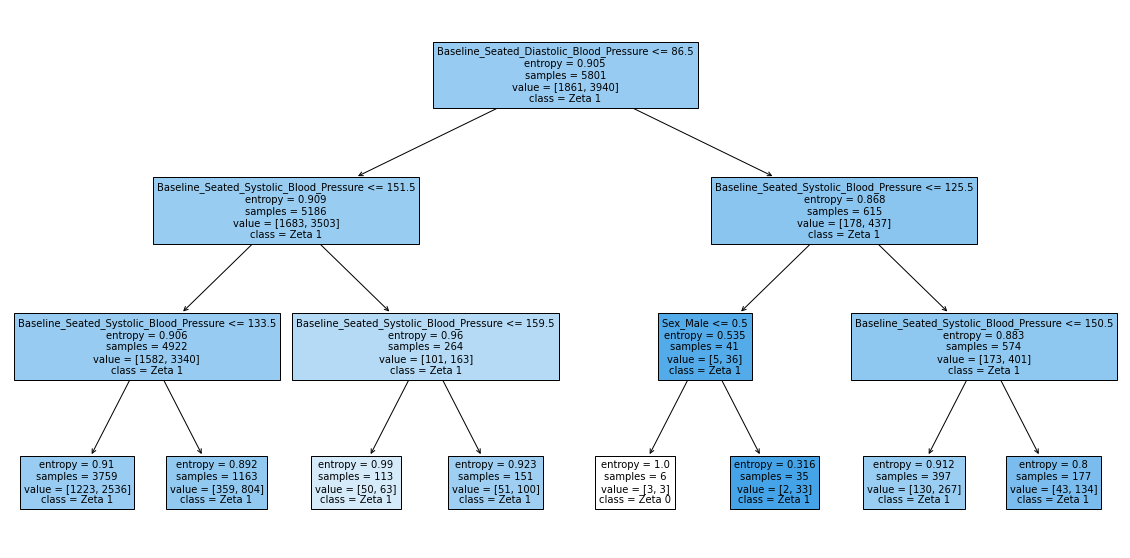

In [15]:
# Let's check out the tree
plt.figure(figsize=(20,10))
tree.plot_tree(dt_model, feature_names=features_dt.columns, class_names=['Zeta 0', 'Zeta 1'], fontsize=10, filled=True)
plt.show()